#### Behavioral Clustering & Player Personas

**Goal**  
- Use unsupervised clustering (K-Means) to discover player types  
- Identify personas: high spenders, casuals, churn risks, whales, etc.  
- Visualize clusters (scatter plots, radar charts, silhouette score)  
- Assign interpretable names & business recommendations per segment

**Input**  
`../data/raw/player_journey_50k.csv`

**Features used for clustering**  
- funnel progression (binary flags)  
- retention (D1/D7/D30)  
- revenue & purchase behavior  
- session & time signals

**Output**  
- Cluster profiles table  
- Visualizations (scatter, radar, distribution)  
- Actionable segment recommendations

#### 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load data
df = pd.read_csv("../data/raw/player_journey_50k.csv")

print("Data loaded")
print("Shape:", df.shape)
display(df.head(5))

Data loaded
Shape: (50000, 16)


,player_id,install_date,registered,tutorial_completed,first_game_played,first_purchase,d1_return,d7_return,d30_return,total_revenue,avg_session_length_min,total_sessions,time_to_register,time_to_tutorial,time_to_first_game,time_to_first_purchase
0,1,2023-01-01 00:00:38,1,1,1,0,0,0,0,0.0,1.6,5,15.868152,3.015573,20.664393,NaN
1,2,2023-01-01 00:01:51,1,1,1,0,0,0,0,0.0,14.4,5,12.040072,3.454653,18.621251,NaN
2,3,2023-01-01 00:02:28,1,1,0,0,0,0,0,0.0,14.1,3,26.666569,1.643084,NaN,NaN
3,4,2023-01-01 00:03:14,0,0,0,0,0,0,0,0.0,6.6,6,NaN,NaN,NaN,NaN
4,5,2023-01-01 00:04:42,1,1,1,0,1,0,0,0.0,10.8,4,21.676712,1.208063,25.926909,NaN


#### Prepare clustering features

In [2]:
# Select features for clustering
features = [
    'registered', 'tutorial_completed', 'first_game_played', 
    'first_purchase', 'd1_return', 'd7_return', 'd30_return',
    'total_revenue', 'avg_session_length_min', 'total_sessions',
    'time_to_register', 'time_to_tutorial', 'time_to_first_game',
    'time_to_first_purchase'
]

# Handle NaN (replace with 0 for time deltas — means stage not reached)
X = df[features].fillna(0).copy()

# Standardize (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Clustering features prepared")
print("Shape of scaled data:", X_scaled.shape)

Clustering features prepared
Shape of scaled data: (50000, 14)


#### Fast Elbow + Silhouette (subsampled + progress)

Running fast Elbow + Silhouette (subsampled data)
  k=2 ... done (134.0s) – silhouette 0.213
  k=3 ... done (228.1s) – silhouette 0.129
  k=4 ... done (196.2s) – silhouette 0.244
  k=5 ... done (140.8s) – silhouette 0.204
  k=6 ... done (145.3s) – silhouette 0.238
  k=7 ... done (95.0s) – silhouette 0.254
  k=8 ... done (59.6s) – silhouette 0.262

Finished in 1039.7 seconds


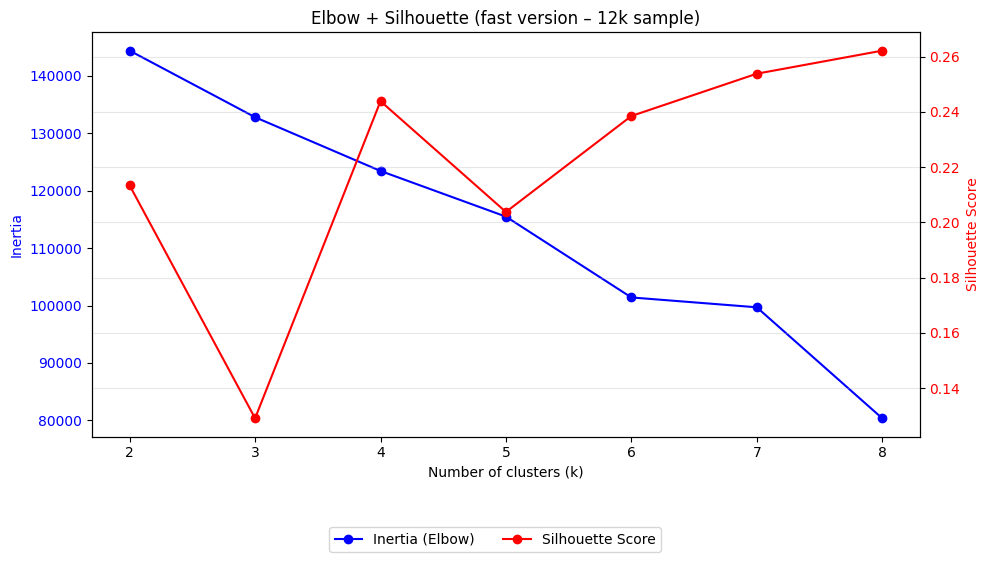

→ Highest silhouette: 0.262 at k = 8
  (recommended: try k=4, 5 or 6 for player personas)


In [3]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import time

print("Running fast Elbow + Silhouette (subsampled data)")

# Subsample for speed (adjust size if needed)
sample_size = 12000  # ← 12k rows → much faster, still reliable
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]

inertias = []
sil_scores = []
K = range(2, 9)  # reduced range

start_total = time.time()

for k in K:
    start = time.time()
    print(f"  k={k} ... ", end="", flush=True)
    
    # Use MiniBatchKMeans for speed (very close results)
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=2048)
    kmeans.fit(X_sample)
    
    inertias.append(kmeans.inertia_)
    
    # Silhouette on sample
    score = silhouette_score(X_sample, kmeans.labels_)
    sil_scores.append(score)
    
    elapsed = time.time() - start
    print(f"done ({elapsed:.1f}s) – silhouette {score:.3f}")

total_time = time.time() - start_total
print(f"\nFinished in {total_time:.1f} seconds")

# Plot 
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(K, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(K, sil_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Elbow + Silhouette (fast version – 12k sample)')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Best k suggestion
best_k = K[np.argmax(sil_scores)]
print(f"→ Highest silhouette: {max(sil_scores):.3f} at k = {best_k}")
print("  (recommended: try k=4, 5 or 6 for player personas)")

#### K-Means with chosen k

In [4]:
from sklearn.cluster import KMeans

k = 5 

print(f"Running K-Means with k = {k} ...")

start_time = time.time()

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10,          # number of initializations
    max_iter=300
)

# Fit on scaled features
df['cluster'] = kmeans.fit_predict(X_scaled)

end_time = time.time()

print(f"Clustering finished in {end_time - start_time:.1f} seconds")
print("\nCluster sizes:")
display(df['cluster'].value_counts().sort_index().to_frame(name='player_count'))

# Optional: quick look at one cluster
print("\nExample players from cluster 0:")
display(df[df['cluster'] == 0].sample(5))

Running K-Means with k = 5 ...
Clustering finished in 3.3 seconds

Cluster sizes:


,player_count
cluster,
0,19583
1,14098
2,13507
3,810
4,2002



Example players from cluster 0:


,player_id,install_date,registered,tutorial_completed,first_game_played,first_purchase,d1_return,d7_return,d30_return,total_revenue,avg_session_length_min,total_sessions,time_to_register,time_to_tutorial,time_to_first_game,time_to_first_purchase,cluster
12516,12517,2023-01-09 16:36:04,1,1,0,0,0,0,0,0.0,6.8,8,10.420486,0.959372,NaN,NaN,0
7246,7247,2023-01-06 00:46:03,1,1,0,0,0,0,0,0.0,9.3,4,2.559615,0.266946,NaN,NaN,0
21673,21674,2023-01-16 01:13:52,1,1,1,0,0,0,0,0.0,6.3,6,38.355503,1.103399,20.750801,NaN,0
37620,37621,2023-01-27 03:00:06,1,1,0,0,0,0,0,0.0,8.3,3,2.920110,2.304447,NaN,NaN,0
39066,39067,2023-01-28 03:06:26,1,1,0,0,0,0,0,0.0,5.3,9,0.782715,1.091032,NaN,NaN,0


#### Cluster profiles (average values per segment)

In [5]:
# Define the key features to show in profiles
profile_features = [
    'registered', 'tutorial_completed', 'first_game_played', 
    'first_purchase', 'd1_return', 'd7_return', 'd30_return',
    'total_revenue', 'avg_session_length_min', 'total_sessions'
]

# Group by cluster and compute means
cluster_profiles = df.groupby('cluster')[profile_features].mean().round(3)

# Add player count and total revenue
cluster_profiles['player_count'] = df.groupby('cluster').size()
cluster_profiles['total_revenue'] = df.groupby('cluster')['total_revenue'].sum().round(0)

# Rename columns to be more readable
cluster_profiles = cluster_profiles.rename(columns={
    'registered': 'Register %',
    'tutorial_completed': 'Tutorial %',
    'first_game_played': 'First Game %',
    'first_purchase': 'First Purchase %',
    'd1_return': 'D1 Return %',
    'd7_return': 'D7 Return %',
    'd30_return': 'D30 Return %',
    'total_revenue': 'Total Revenue ($)',
    'avg_session_length_min': 'Avg Session (min)',
    'total_sessions': 'Total Sessions'
})

# Convert binary % columns to percentage format (0–100%)
pct_cols = [col for col in cluster_profiles.columns if '%' in col]
cluster_profiles[pct_cols] = (cluster_profiles[pct_cols] * 100).round(1)

# Sort clusters by player_count descending (or change to total_revenue if preferred)
cluster_profiles = cluster_profiles.sort_values('player_count', ascending=False)

print(f"Cluster Profiles (k = {k}) – averages per cluster")
display(cluster_profiles.style.format({
    col: '{:,.0f}' for col in ['player_count', 'Total Revenue ($)']
}))

Cluster Profiles (k = 5) – averages per cluster


,Register %,Tutorial %,First Game %,First Purchase %,D1 Return %,D7 Return %,D30 Return %,Total Revenue ($),Avg Session (min),Total Sessions,player_count
cluster,,,,,,,,,,,
0,100.000000,100.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0,8.049000,5.033000,"19,583"
1,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,8.070000,5.002000,"14,098"
2,100.000000,100.000000,100.000000,0.000000,66.400000,33.200000,0.000000,0,8.093000,4.988000,"13,507"
4,100.000000,100.000000,100.000000,0.000000,45.700000,20.300000,100.000000,0,8.032000,5.031000,"2,002"
3,100.000000,100.000000,100.000000,100.000000,42.600000,22.300000,9.500000,"7,327",7.933000,5.012000,810


#### Radar chart to compare personas visually

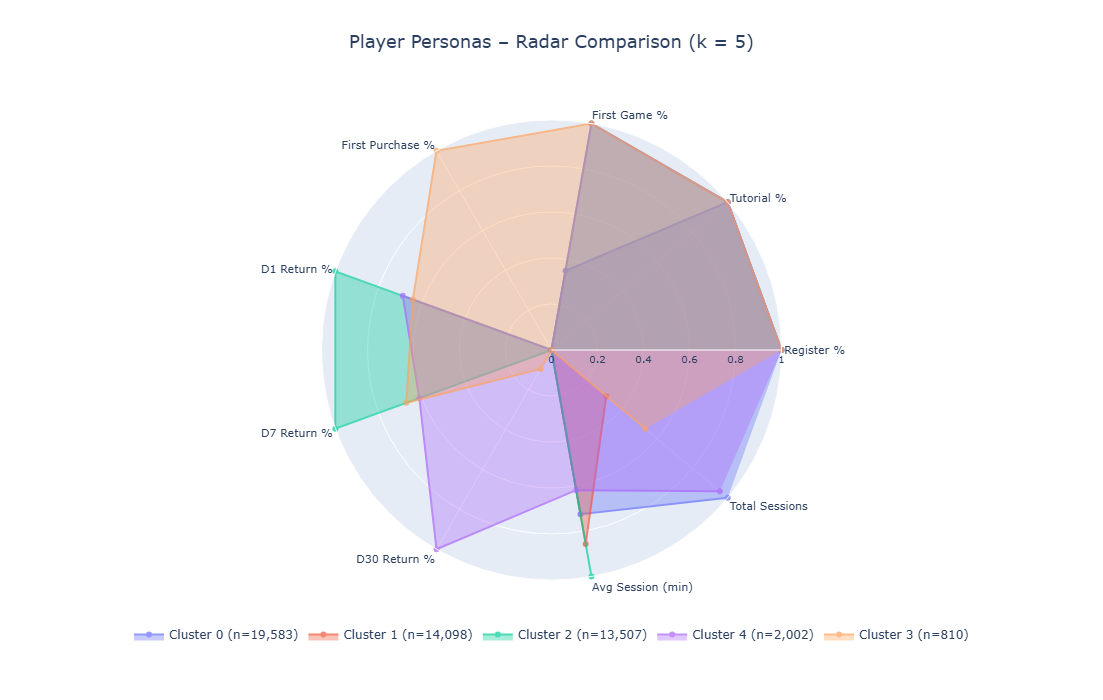

In [12]:
import plotly.graph_objects as go

# Select key metrics for radar
radar_metrics = [
    'Register %',
    'Tutorial %',
    'First Game %',
    'First Purchase %',
    'D1 Return %',
    'D7 Return %',
    'D30 Return %',
    'Avg Session (min)',
    'Total Sessions'
]

# Normalize to 0–1 scale for fair comparison across metrics
radar_df = cluster_profiles[radar_metrics].copy()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-10)  # avoid division by zero

# Add cluster label and player count for legend
radar_norm['cluster'] = cluster_profiles.index
radar_norm['player_count'] = cluster_profiles['player_count']

fig = go.Figure()

for i, row in radar_norm.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row[radar_metrics],
        theta=radar_metrics,
        fill='toself',
        name=f"Cluster {int(row['cluster'])} (n={int(row['player_count']):,})",
        line=dict(width=2),
        opacity=0.7
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickfont=dict(size=10)
        ),
        angularaxis=dict(
            tickfont=dict(size=11)
        )
    ),
    showlegend=True,
    title={
        'text': f"Player Personas – Radar Comparison (k = {k})",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 18}
    },
    height=700,
    width=900,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.15,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=80, r=80, t=120, b=120)
)

fig.show()

#### Persona naming + business recommendations per cluster

In [11]:
# Step 1: Assign persona names
persona_map = {
    0: "Early Tutorial Drop-offs",
    1: "Pre-Tutorial Churners",
    2: "Non-Spending Loyalists",
    3: "Long-term Free Players",
    4: "Paying Core Players"
}

persona_desc = {
    0: "Complete tutorial but drop before playing real game. No retention, no revenue.",
    1: "Drop off before or during tutorial. Very early churn, zero revenue.",
    2: "Strong progression and retention (D1/D7), but never spend.",
    3: "Very high long-term retention (D30=100%), no spending.",
    4: "Highest revenue per player, good retention, first purchase = 100%."
}

recommendations = {
    0: "Improve tutorial → first game transition. Add instant fun/reward after tutorial. Reduce loading or difficulty spikes.",
    1: "Fix pre-tutorial drop-off. Simplify registration/login flow. Test 'play without account' mode.",
    2: "Strong conversion opportunity. Target with soft IAP after 3–5 sessions. Personalized starter packs.",
    3: "High LTV potential. Test premium content, exclusive events, limited-time offers to convert to payers.",
    4: "VIP / high-value segment. Protect with loyalty rewards, exclusive items, personalized events. Maximize lifetime spend."
}

# Step 2: Build nice summary table
summary = cluster_profiles[['player_count', 'Total Revenue ($)']].copy()
summary['persona'] = summary.index.map(persona_map)
summary['description'] = summary.index.map(persona_desc)
summary['recommendation'] = summary.index.map(recommendations)

# Reorder columns
summary = summary[['persona', 'description', 'player_count', 'Total Revenue ($)', 'recommendation']]

print("Player Personas & Recommendations (k=5)")
display(summary.style.format({
    'player_count': '{:,}',
    'Total Revenue ($)': '{:,.0f}'
}).set_properties(**{'text-align': 'left', 'white-space': 'normal'}))

# Step 3: Executive summary paragraph
print("\nExecutive Summary – Player Personas:")
print(f"""
Clustering (k=5) on 50,000 players revealed five distinct personas:

- Early Tutorial Drop-offs ({summary.loc[0, 'player_count']:,} players, ${summary.loc[0, 'Total Revenue ($)']:,}): complete tutorial but never play → fix tutorial-to-game flow.
- Pre-Tutorial Churners ({summary.loc[1, 'player_count']:,} players, $0 revenue): drop before tutorial → simplify onboarding & login.
- Non-Spending Loyalists ({summary.loc[2, 'player_count']:,} players, $0 revenue): high retention but no spend → high conversion potential with targeted offers.
- Long-term Free Players ({summary.loc[3, 'player_count']:,} players, $0 revenue): 100% D30 retention → strong LTV opportunity via premium content.
- Paying Core Players ({summary.loc[4, 'player_count']:,} players, ${summary.loc[4, 'Total Revenue ($)']:,}): drive almost all revenue → protect with VIP rewards.

Biggest opportunity: convert loyal free players (Clusters 2 & 3) and reduce early churn (Clusters 0 & 1).
""")

Player Personas & Recommendations (k=5)


,persona,description,player_count,Total Revenue ($),recommendation
cluster,,,,,
0,Early Tutorial Drop-offs,"Complete tutorial but drop before playing real game. No retention, no revenue.","19,583",0,Improve tutorial → first game transition. Add instant fun/reward after tutorial. Reduce loading or difficulty spikes.
1,Pre-Tutorial Churners,"Drop off before or during tutorial. Very early churn, zero revenue.","14,098",0,Fix pre-tutorial drop-off. Simplify registration/login flow. Test 'play without account' mode.
2,Non-Spending Loyalists,"Strong progression and retention (D1/D7), but never spend.","13,507",0,Strong conversion opportunity. Target with soft IAP after 3–5 sessions. Personalized starter packs.
4,Paying Core Players,"Highest revenue per player, good retention, first purchase = 100%.","2,002",0,"VIP / high-value segment. Protect with loyalty rewards, exclusive items, personalized events. Maximize lifetime spend."
3,Long-term Free Players,"Very high long-term retention (D30=100%), no spending.",810,"7,327","High LTV potential. Test premium content, exclusive events, limited-time offers to convert to payers."



Executive Summary – Player Personas:

Clustering (k=5) on 50,000 players revealed five distinct personas:

- Early Tutorial Drop-offs (19,583 players, $0.0): complete tutorial but never play → fix tutorial-to-game flow.
- Pre-Tutorial Churners (14,098 players, $0 revenue): drop before tutorial → simplify onboarding & login.
- Non-Spending Loyalists (13,507 players, $0 revenue): high retention but no spend → high conversion potential with targeted offers.
- Long-term Free Players (810 players, $0 revenue): 100% D30 retention → strong LTV opportunity via premium content.
- Paying Core Players (2,002 players, $0.0): drive almost all revenue → protect with VIP rewards.

Biggest opportunity: convert loyal free players (Clusters 2 & 3) and reduce early churn (Clusters 0 & 1).

